In [2]:
import trajectory_pipeline_v2 as trajectory_pipeline
from trajectory_pipeline_v2 import *
import os

12.31069849314926


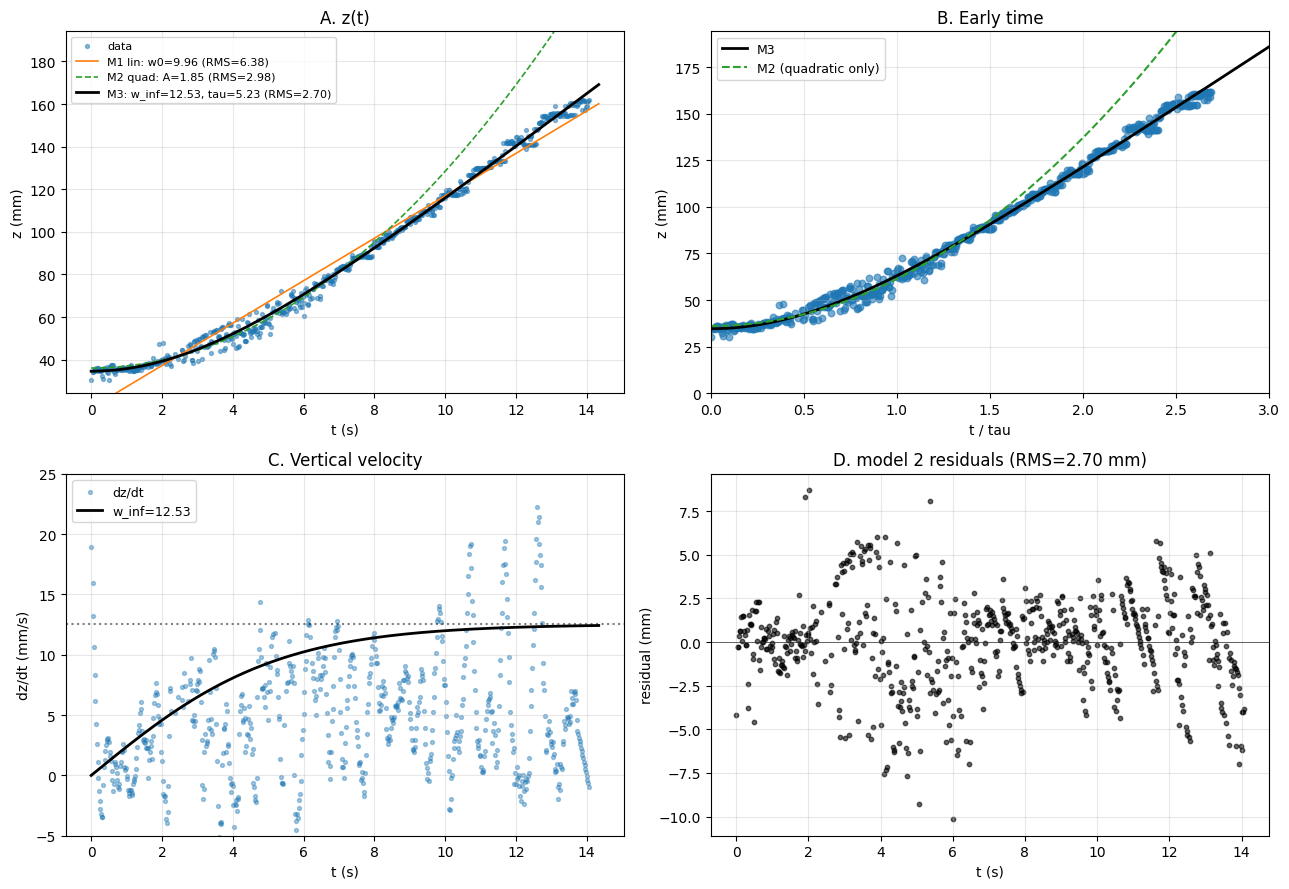

In [4]:
filepath = '/mnt/d/Users/zl483/digiflow/trajectories/test30/new_trajectory.csv'

V_bubble = 20  # in micro-liter
U_piston = 120 # in mm/s
R_ring = 23 # in mm
a_core = 10 # in mm

results = trajectory_pipeline.analyse_shot(filepath, V_bubble, U_piston, R_ring, a_core)
fig = plot_shot_diagnostics(results)
print(results['V_b_fit_uL'])


=== Joint Model-3 fit (5 shots) ===
C_d,eff = 2.206 +/- 0.285
C_AM    = 1.222 +/- 0.290
corr(C_d, C_AM) = +0.966
  Consider pinning V_b from bubble counting (sec 1.2).
NLL at optimum = 13557.9515
converged: True  (CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH)


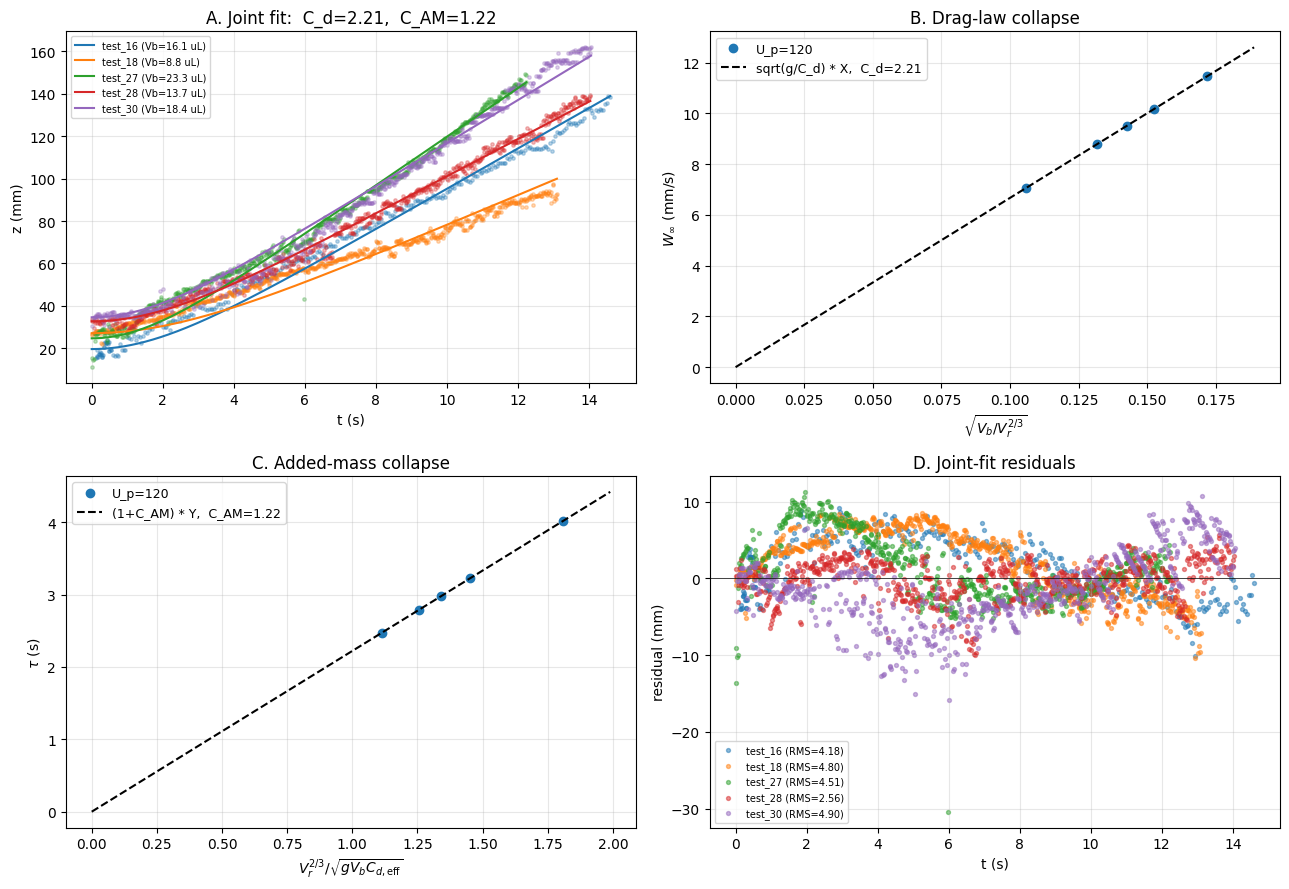

In [5]:

from joint_fit import joint_fit_shots, plot_joint_fit_diagnostics, profile_likelihood

# 1. Run your usual per-shot pipeline on the U_p=120 shots
shot_specs = [
    # ('/mnt/d/Users/zl483/digiflow/trajectories/test15/new_trajectory.csv', 40, 120, 'test_15'),
    ('/mnt/d/Users/zl483/digiflow/trajectories/test16/new_trajectory.csv', 20, 120, 'test_16'),
    ('/mnt/d/Users/zl483/digiflow/trajectories/test18/new_trajectory.csv', 20, 120, 'test_18'),
    # ('/mnt/d/Users/zl483/digiflow/trajectories/test19/new_trajectory.csv', 40, 120, 'test_19'),
    # ('/mnt/d/Users/zl483/digiflow/trajectories/test23/new_trajectory.csv', 40, 120, 'test_23'),#
    # ('/mnt/d/Users/zl483/digiflow/trajectories/test24/new_trajectory.csv', 20, 120, 'test_24'),
    # ('/mnt/d/Users/zl483/digiflow/trajectories/test26/new_trajectory.csv', 40, 120, 'test_26'), 
    ('/mnt/d/Users/zl483/digiflow/trajectories/test27/new_trajectory.csv', 40, 120, 'test_27'),
    ('/mnt/d/Users/zl483/digiflow/trajectories/test28/new_trajectory.csv', 40, 120, 'test_28'),
    ('/mnt/d/Users/zl483/digiflow/trajectories/test30/new_trajectory.csv', 20, 120, 'test_30')
    # ...
]
per_shot = [analyse_shot(p, V_b_uL=V, U_p=U, label=lab)
            for p, V, U, lab in shot_specs]

# 2. Joint fit (defaults: t_max = all cleaned data, baseline = first 20 frames)
joint = joint_fit_shots(per_shot, n_baseline_frames=20)

# 3. Diagnostics
plot_joint_fit_diagnostics(joint, savepath='joint_fit.png')

# 4. Profile-likelihood CI for the global params (slower but more honest
#    than the Hessian interval given the parameter correlation)
prof_Cd  = profile_likelihood(joint, param='C_d',  level=0.95)
prof_CAM = profile_likelihood(joint, param='C_AM', level=0.95)

In [6]:
joint['summary']

,label,U_p,V_b_nominal_uL,V_b_fit_uL,V_b_fit_se_uL,z_launch_mm,W_inf_mm_s,tau_s,n_points,rms_mm
0,test_16,120,20,16.076331,2.071288,19.6940,9.506961,2.979485,312,4.184977
1,test_18,120,20,8.837180,1.139815,27.1795,7.048636,4.018628,656,4.798924
2,test_27,120,40,23.333243,3.004718,24.7620,11.453436,2.473131,613,4.514866
3,test_28,120,40,13.735521,1.767997,32.7587,8.787611,3.223384,687,2.563432
4,test_30,120,20,18.359039,2.364175,34.6610,10.159521,2.788108,676,4.903484


quadratic coeff for test_16: 9.377728174335916
fitted V_b for test_16: 23.18482516654038 uL


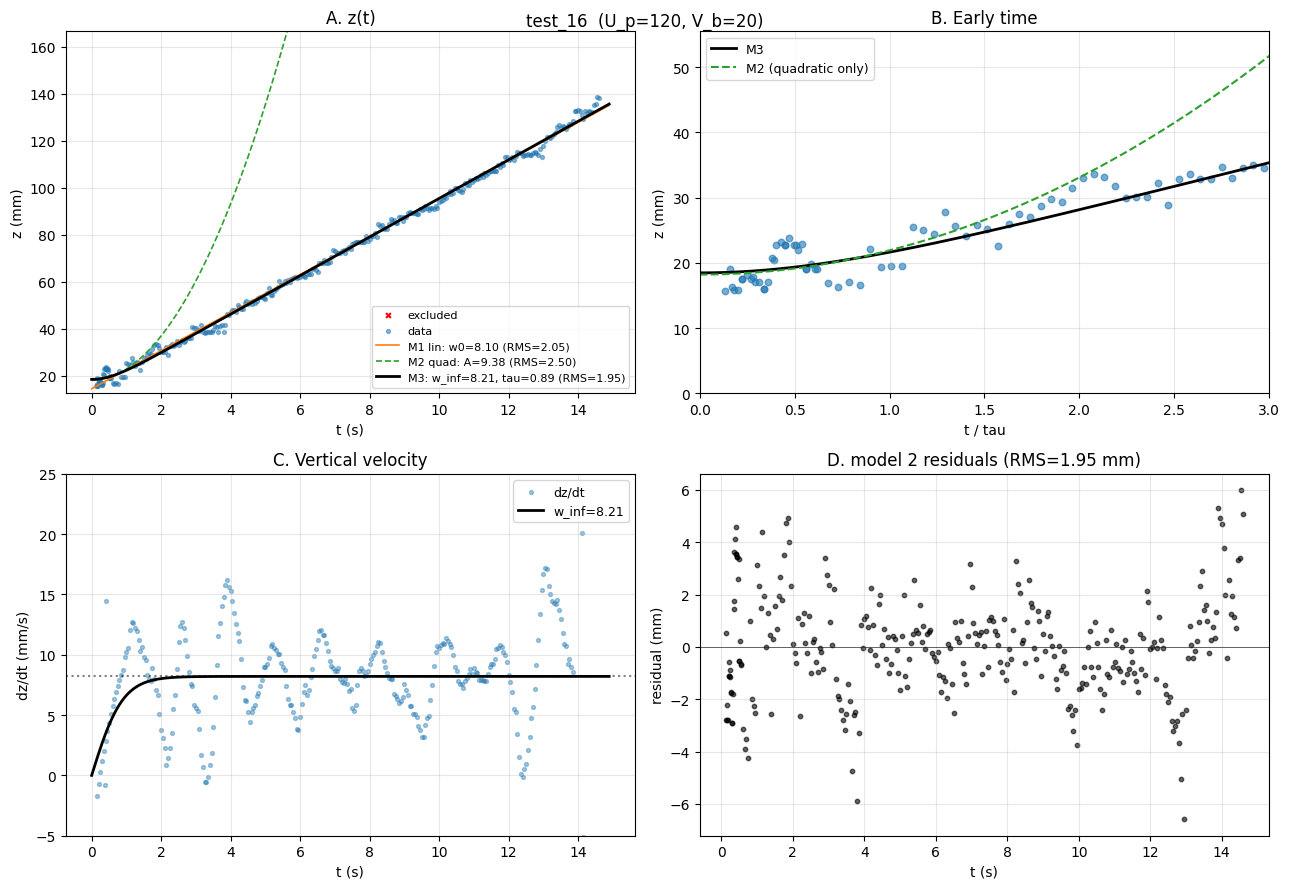

quadratic coeff for test_18: 8.330742127467433
fitted V_b for test_18: 31.389626338581564 uL


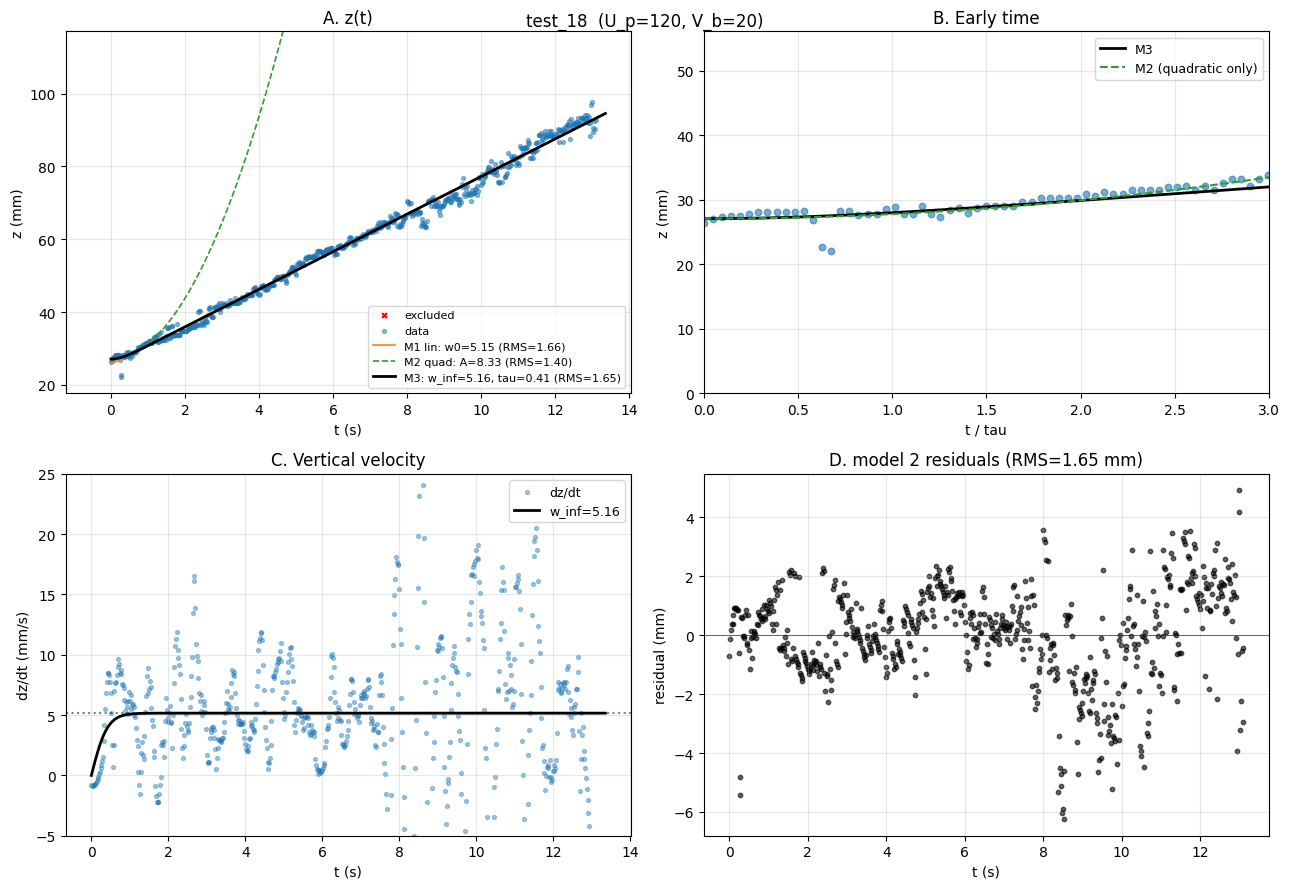

quadratic coeff for test_27: 2.9021388228545155
fitted V_b for test_27: 8.275208756456212 uL


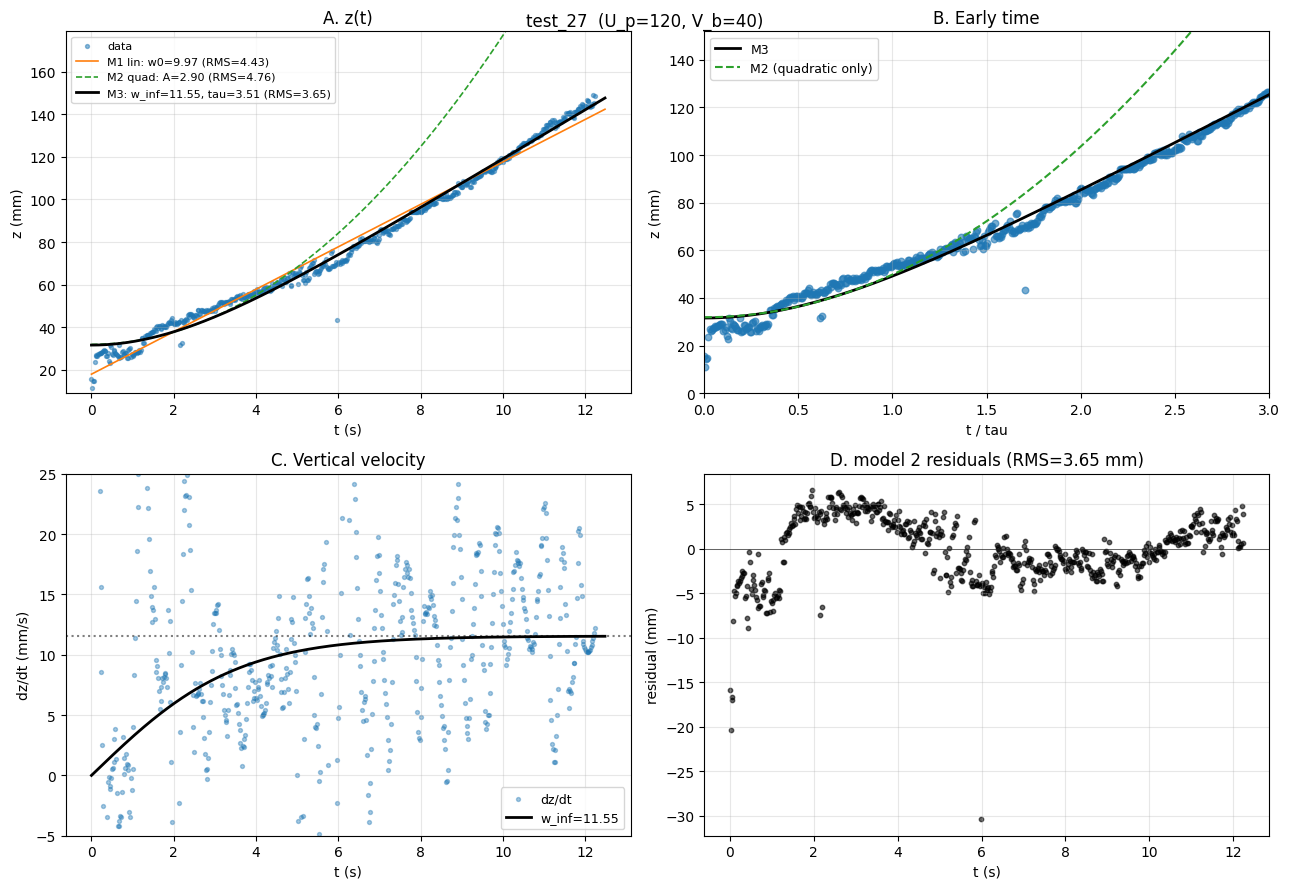

quadratic coeff for test_28: 1.893076422422058
fitted V_b for test_28: 5.999387529534055 uL


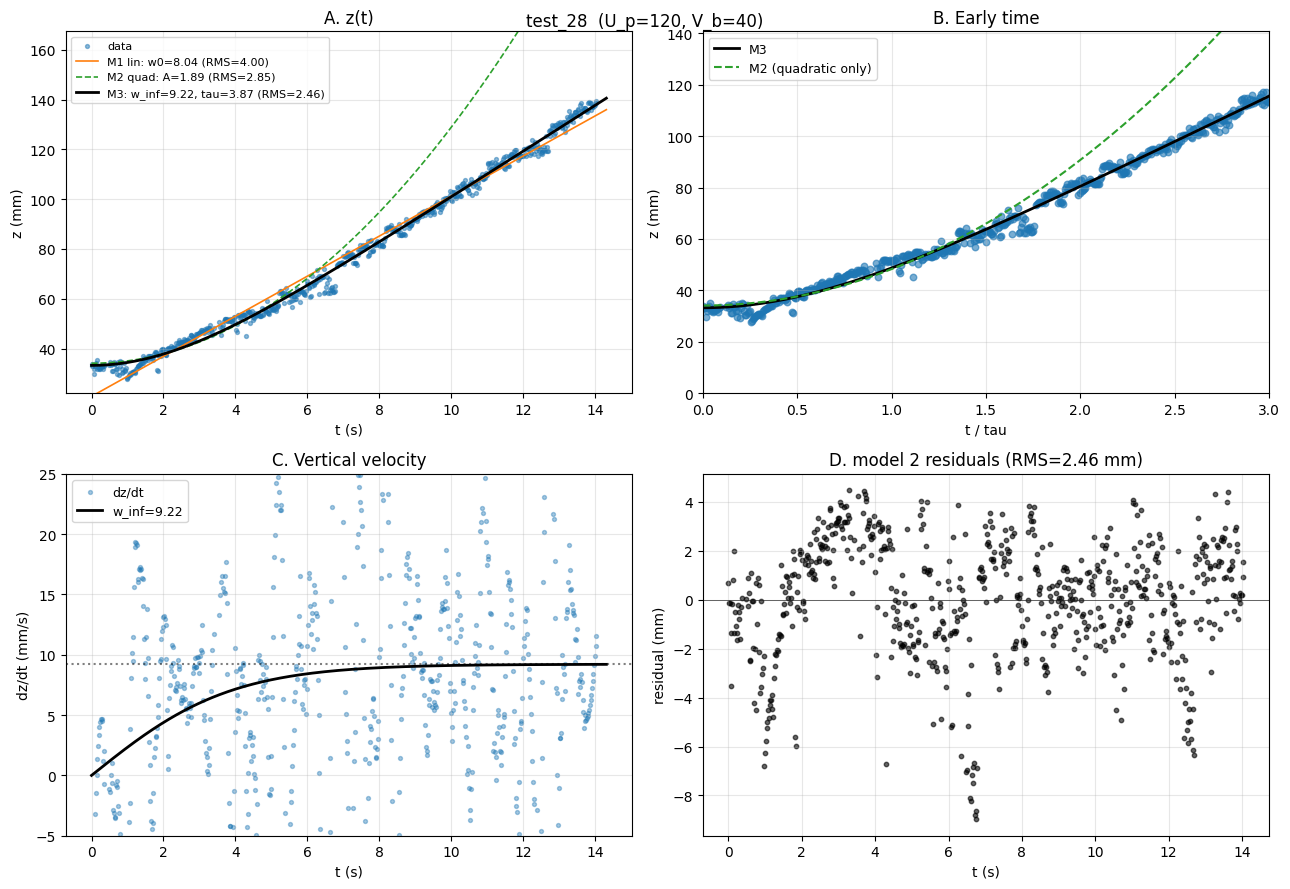

quadratic coeff for test_30: 1.8464574952134134
fitted V_b for test_30: 6.032242261643137 uL


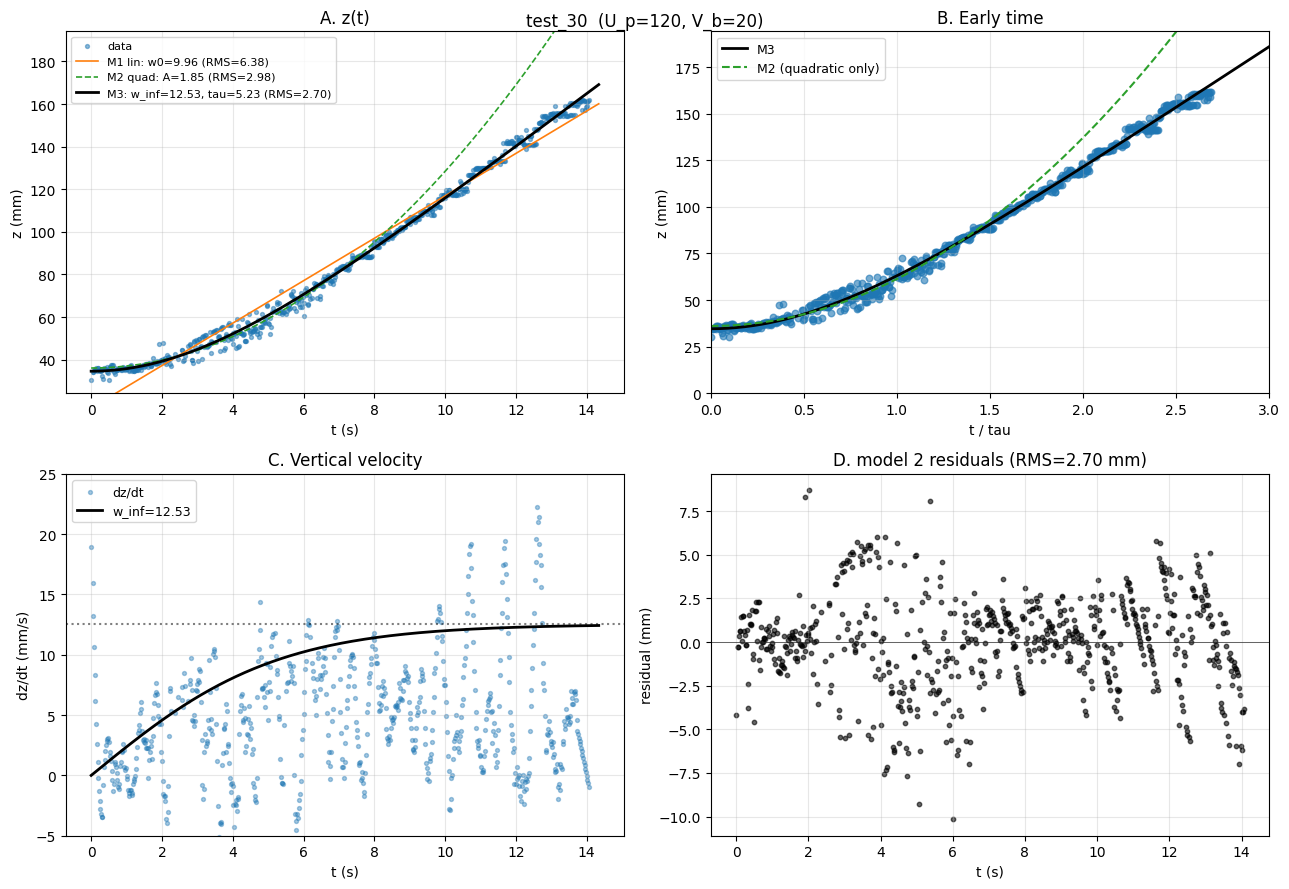

In [7]:
import matplotlib.pyplot as plt
from trajectory_pipeline import plot_shot_diagnostics

for res in per_shot:
    fig = plot_shot_diagnostics(res)
    fig.suptitle(f"{res['label']}  (U_p={res['U_p']}, V_b={res['V_b_uL']})")
    quadratic_coeff = res['model3']['params'][1]
    print(f'quadratic coeff for {res["label"]}: {quadratic_coeff}')
    print(f'fitted V_b for {res["label"]}: {res["V_b_fit_uL"]} uL')
    plt.show()